In [1]:
import sys
sys.path.append('..')
from src.preprocess import load_and_preprocess
from sklearn.model_selection import train_test_split

X, y = load_and_preprocess()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Fetching KDD Cup 99 dataset...
Dataset shape: (494021, 15)
Label distribution:
attack_category
DoS       391458
Normal     97278
Probe       4107
R2L         1126
U2R           52
Name: count, dtype: int64
Train: (395216, 15) | Test: (98805, 15)


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=20, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
}

results = {}
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    results[name] = acc
    print(f"{name}: {acc*100:.2f}% ({time.time()-start:.1f}s)")

Logistic Regression: 98.60% (16.6s)
Decision Tree: 99.95% (1.4s)
Random Forest: 99.96% (6.1s)


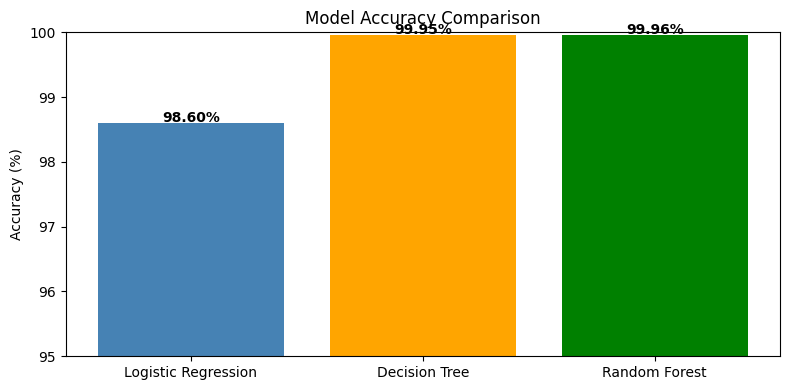

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8,4))
plt.bar(results.keys(), [v*100 for v in results.values()],
        color=['steelblue','orange','green'])
plt.ylabel('Accuracy (%)')
plt.title('Model Accuracy Comparison')
plt.ylim(95, 100)
for i, (k, v) in enumerate(results.items()):
    plt.text(i, v*100+0.02, f'{v*100:.2f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/model_comparison.png')
plt.show()